<a href="https://colab.research.google.com/github/Abdullah-Abdualigah/wids-datathon-2026/blob/main/temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imoprt Librarys

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load data + description

In [ ]:

def loadFiles():
    PATH = '/content/drive/MyDrive/project files/'
    metaData = pd.read_csv(PATH + 'metaData.csv')
    sampleSubmission =pd.read_csv( PATH + 'sample_submission.csv')
    test =pd.read_csv( PATH + 'test.csv')
    train =pd.read_csv( PATH + 'train.csv')
    return metaData , sampleSubmission , train , test

metaData , sampleSubmission , train , test = loadFiles()

In [ ]:
metaData

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN
5,low_temporal_resolution_0_5h,feature,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0",NaN,NaN
6,area_first_ha,feature,growth,Initial fire area at t0 (hectares),NaN,NaN
7,area_growth_abs_0_5h,feature,growth,Feature from growth category,NaN,NaN
8,area_growth_rel_0_5h,feature,growth,Feature from growth category,NaN,NaN
9,area_growth_rate_ha_per_h,feature,growth,Area growth rate (hectares per hour),NaN,NaN


In [ ]:
metaData.describe()

,column,type,category,description,units,range
count,37,37,37,37,1,1
unique,37,3,8,18,1,1
top,event_id,feature,growth,Feature from growth category,hours,"[0, 72]"
freq,1,34,10,8,1,1


In [ ]:
metaData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   column       37 non-null     object
 1   type         37 non-null     object
 2   category     37 non-null     object
 3   description  37 non-null     object
 4   units        1 non-null      object
 5   range        1 non-null      object
dtypes: object(6)
memory usage: 1.9+ KB


In [ ]:
sampleSubmission

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5
...,...,...,...,...,...
90,94627327,0.5,0.5,0.5,0.5
91,96570675,0.5,0.5,0.5,0.5
92,97225766,0.5,0.5,0.5,0.5
93,98446281,0.5,0.5,0.5,0.5


In [ ]:
sampleSubmission.describe()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
count,9.500000e+01,95.0,95.0,95.0,95.0
mean,5.695393e+07,0.5,0.5,0.5,0.5
std,2.329721e+07,0.0,0.0,0.0,0.0
min,1.066260e+07,0.5,0.5,0.5,0.5
25%,4.027536e+07,0.5,0.5,0.5,0.5
50%,5.480111e+07,0.5,0.5,0.5,0.5
75%,7.536942e+07,0.5,0.5,0.5,0.5
max,9.964946e+07,0.5,0.5,0.5,0.5


In [ ]:
sampleSubmission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   event_id  95 non-null     int64  
 1   prob_12h  95 non-null     float64
 2   prob_24h  95 non-null     float64
 3   prob_48h  95 non-null     float64
 4   prob_72h  95 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 3.8 KB


Train data

In [ ]:
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [ ]:
train.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,...,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,...,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,...,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,...,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,...,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

Test data

In [ ]:
test.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


In [ ]:
test.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
count,9.500000e+01,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,...,95.000000,9.500000e+01,95.00000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,5.695393e+07,1.926316,0.832315,0.778947,891.299795,3.127903,0.084938,0.726143,4.766501,0.234737,...,3.047023,-1.745125e+00,0.02777,-0.017654,0.128012,-0.869447,0.765021,14.610526,2.547368,6.800000
std,2.329721e+07,2.965196,1.650526,0.417157,2144.075209,15.266385,0.416592,3.551966,2.184843,0.913950,...,38.782057,9.640486e+00,0.13214,0.310422,0.283047,17.835884,9.145756,8.558055,1.761095,1.692285
min,1.066260e+07,1.000000,0.000000,0.000000,0.396510,0.000000,0.000000,0.000000,0.333976,0.000000,...,-155.180637,-8.414432e+01,0.00000,-0.999964,0.000000,-105.986133,-35.949759,0.000000,0.000000,1.000000
25%,4.027536e+07,1.000000,0.000000,1.000000,25.561885,0.000000,0.000000,0.000000,3.278582,0.000000,...,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,6.000000
50%,5.480111e+07,1.000000,0.000000,1.000000,84.586007,0.000000,0.000000,0.000000,4.449522,0.000000,...,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000,19.000000,2.000000,7.000000
75%,7.536942e+07,1.000000,0.000000,1.000000,632.579516,0.000000,0.000000,0.000000,6.438102,0.000000,...,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000,21.000000,4.000000,8.000000
max,9.964946e+07,19.000000,4.884515,1.000000,11964.104587,121.449247,3.202315,29.006158,9.389750,4.807697,...,295.574390,1.591462e-11,0.77497,0.926938,0.999964,98.356413,72.059694,23.000000,6.000000,9.000000


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      95 non-null     int64  
 1   num_perimeters_0_5h           95 non-null     int64  
 2   dt_first_last_0_5h            95 non-null     float64
 3   low_temporal_resolution_0_5h  95 non-null     int64  
 4   area_first_ha                 95 non-null     float64
 5   area_growth_abs_0_5h          95 non-null     float64
 6   area_growth_rel_0_5h          95 non-null     float64
 7   area_growth_rate_ha_per_h     95 non-null     float64
 8   log1p_area_first              95 non-null     float64
 9   log1p_growth                  95 non-null     float64
 10  log_area_ratio_0_5h           95 non-null     float64
 11  relative_growth_0_5h          95 non-null     float64
 12  radial_growth_m               95 non-null     float64
 13  radial_

Competition constants

In [ ]:
HORIZONS = [12, 24, 48, 72]
PROB_COLS = [f"prob_H{h}" for h in HORIZONS]

ID_COL = "event_id"
TARGET_TIME = "time_to_hit_hours"
TARGET_EVENT = "event"

Rate of events (hits within 72 hours)

In [ ]:

event_rate = train[TARGET_EVENT].mean()
print(f"Event rate (hit within 72 hours): {event_rate:.4f}")

Event rate (hit within 72 hours): 0.3122


Min/Max time_to_hit_hours and count of censored events (time==72)

In [ ]:
print(f"Min/Max time_to_hit_hours: {train[TARGET_TIME].min()}/{train[TARGET_TIME].max()}")
print(f"count time==72: {(train[TARGET_TIME] == 72).sum()}")

Min/Max time_to_hit_hours: 0.0012202119444444/66.99447413277778
count time==72: 0


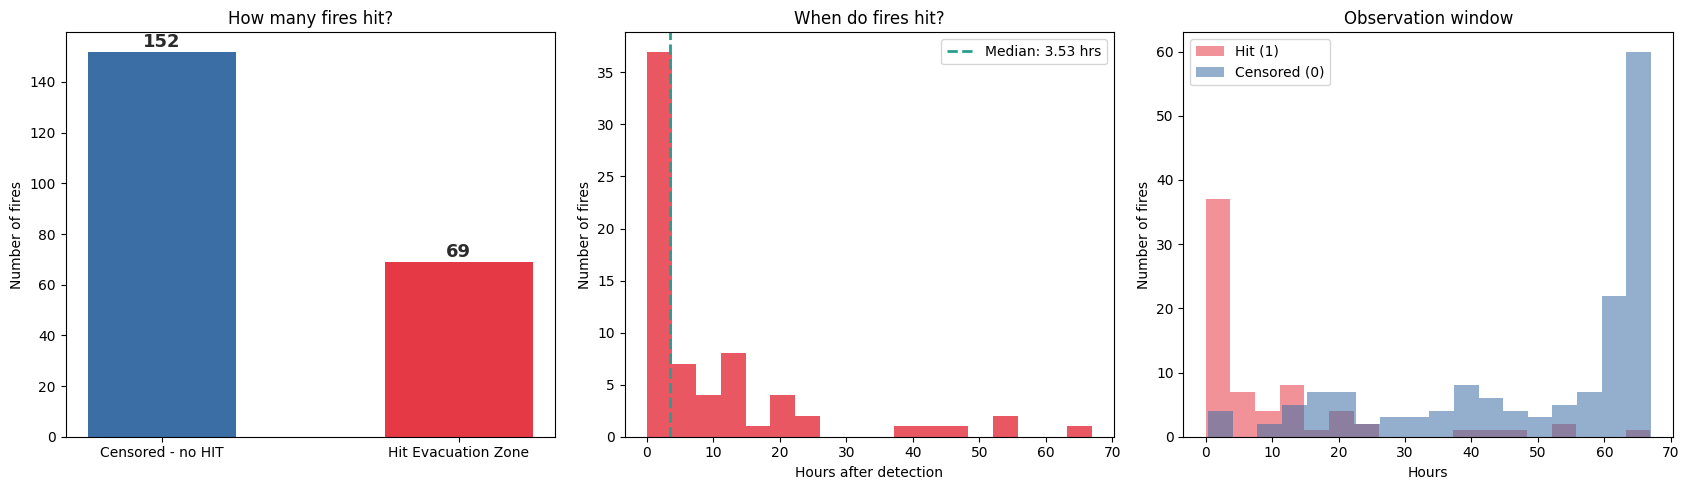

In [ ]:
MISS_COLOR = "#3A6EA5"
HIT_COLOR = "#E63946"
TEXT_COLOR = "#2B2B2B"
FIRE_COLORS = "#2A9D8F"

fig, axes = plt.subplots(1,3, figsize = (17, 5))
counts = train['event'].value_counts().sort_index()
bars = axes[0].bar(
    ['Censored - no HIT', 'Hit Evacuation Zone'],
    counts.values,
    color = [MISS_COLOR, HIT_COLOR],
    edgecolor = 'none',
    width = 0.5
)
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        count + 2,
        str(count),
        ha='center',
        color = TEXT_COLOR,
        fontweight = 'bold',
        fontsize = 13
    )
axes[0].set_title('How many fires hit?')
axes[0].set_ylabel('Number of fires')

hits = train[train['event'] == 1]['time_to_hit_hours']
axes[1].hist(hits, bins = 18, color=HIT_COLOR, alpha = 0.85, edgecolor='none')
axes[1].axvline(
    hits.median(),
    color = FIRE_COLORS,
    ls="--",
    lw = 2,
    label = f'Median: {hits.median():.2f} hrs'
)

axes[1].set_title('When do fires hit?')
axes[1].set_xlabel('Hours after detection')
axes[1].set_ylabel('Number of fires')
axes[1].legend()

for label, color, mask in [
    ('Hit (1)', HIT_COLOR, train['event'] == 1),
    ('Censored (0)', MISS_COLOR, train['event'] == 0)
]:
    axes[2].hist(
        train.loc[mask, 'time_to_hit_hours'],
        bins = 18,
        alpha = 0.55,
        color = color,
        label = label,
        edgecolor = 'none'
    )

axes[2].set_title('Observation window')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Number of fires')
axes[2].legend()

plt.tight_laydata()
plt.show()

data correlation

In [ ]:
feature_cols = [c for c in train.columns if c not in ['event', 'event_id', 'time_to_hit_hours']]

top_n = 40

event_corr = train[feature_cols].corrwith(train['event']).abs().sort_values(ascending=False).head(top_n)
time_corr = train[feature_cols].corrwith(train['time_to_hit_hours']).abs().sort_values(ascending=False).head(top_n)

# Create table
corr_table = pd.DataFrame({
    'Top Event Correlation': event_corr,
    'Top Time Correlation': time_corr
})

display(corr_table)

,Top Event Correlation,Top Time Correlation
alignment_abs,0.349115,0.366923
alignment_cos,0.119933,0.079847
along_track_speed,0.008147,0.023527
area_first_ha,0.181334,0.211212
area_growth_abs_0_5h,0.158327,0.164590
area_growth_rate_ha_per_h,0.172416,0.177191
area_growth_rel_0_5h,0.165975,0.157423
centroid_displacement_m,0.207992,0.212354
centroid_speed_m_per_h,0.209254,0.208943
closing_speed_abs_m_per_h,0.138735,0.166876


feature engineering

In [ ]:
def feature_engineering(df):
    data = df.copy()

    # Clip distance to avoid zero or negative values
    distance = data['dist_min_ci_0_5h'].clip(lower=1)

    # Extract closing speed
    speed = data['closing_speed_m_per_h']

    # Time to contact = distance / speed (avoid division by zero)
    data['time_to_contact'] = distance / speed.clip(lower=0.01)

    # Log transform to reduce effect of large values
    data['log_time_to_contact'] = np.log1p(data['time_to_contact'].clip(0, 5000))

    # Danger indicator combining alignment and speed
    data['danger_vector'] = data['alignment_abs'] * speed

    # Tracking urgency metric
    data['tracking_urgency'] = data['num_perimeters_0_5h'] * speed

    # Fire intensity proxy feature
    data['fire_intensity'] = data['area_growth_rate_ha_per_h'] * data['num_perimeters_0_5h']

    # Replace infinite values with NaN then fill missing values with zero
    data = data.replace([np.inf, -np.inf], np.nan).fillna(0)

    return data

In [ ]:
train_FE = feature_engineering(train)
test_FE = feature_engineering(test)

In [ ]:
train_FE.columns

Index(['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month',
       'time_to_hit_hours', 'event', 'time_to_contact', 'log_time_to_contact',
       'danger_vector', 'tracking_urgency', '

In [ ]:
test_FE.columns

Index(['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month',
       'time_to_contact', 'log_time_to_contact', 'danger_vector',
       'tracking_urgency', 'fire_intensity'],
      dtype=